#Dataset Description
This dataset contains customer product reviews from Amazon. Amazon Customer Reviews (a.k.a. Product Reviews) is one of Amazon’s iconic products. In a period of over two decades since the first review in 1995, millions of Amazon customers have contributed over a hundred million reviews to express opinions and describe their experiences regarding products on the Amazon.com website. This makes Amazon Customer Reviews a rich source of information for academic researchers in the fields of Natural Language Processing (NLP), Information Retrieval (IR), and Machine Learning (ML), amongst others. Accordingly, we are releasing this data to further research in multiple disciplines related to understanding customer product experiences. Specifically, this dataset was constructed to represent a sample of customer evaluations and opinions, variation in the perception of a product across geographical regions, and promotional intent or bias in reviews.

Each record includes:

Product review text
Star rating (1–5)
Helpfulness votes
Verification status
Product metadata, category, title
Vine (paid program) info
Timestamps (not always clean)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("/content/fake reviews dataset.csv", on_bad_lines='skip', engine='python')



In [2]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [3]:
print("Shape:", df.shape)
display(df.head())



Shape: (40432, 4)


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [4]:
print("\nInfo:")
print(df.info())




Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB
None


In [5]:
print("\nBasic description:")
display(df.describe(include="all").T)


Basic description:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
category,40432,10,Kindle_Store_5,4730,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,40432.0,NaN,NaN,NaN,4.256579,1.144354,1.0,4.0,5.0,5.0,5.0
label,40432,2,CG,20216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text_,40432,40412,My dog loves these and it has kept her occupie...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The original labels “CG” and “OR” were replaced with the more interpretable human labels “real” and “fake”. A binary version (0 = real, 1 = fake) was also created for classification models. This improves readability and avoids ambiguity.

In [6]:
df["label_text"] = df["label"].map({"CG": "real", "OR": "fake"})
df["label_bin"]  = df["label_text"].map({"real": 0, "fake": 1})
df = df.dropna(subset=["label_text", "label_bin"])


In [7]:
# Count missing values per column
missing = df.isna().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing)


Missing values per column:
category      0
rating        0
label         0
text_         0
label_text    0
label_bin     0
dtype: int64


In [8]:
df = df.drop_duplicates()


In [9]:
df = df.drop_duplicates(subset=["text_"])


In [10]:
dup = df[df.duplicated("text_", keep=False)]
contradict = dup.groupby("text_")["label_bin"].nunique()
contradict_texts = contradict[contradict > 1].index

df = df[~df["text_"].isin(contradict_texts)]


We removed full-row duplicates and repeated text entries.

Additionally, we conducted a contradiction check: if the same review text appeared with different labels (real vs fake), those rows were removed because they represented inconsistent annotations. This step improves label quality and avoids introducing noise into the model.

In [11]:
df["word_len"] = df["text_"].str.split().apply(len)
df["char_len"] = df["text_"].str.len()


In [12]:
df = df[df["word_len"] > 2]


In [13]:
df = df[df["word_len"] < 500]


Reviews with fewer than 3 words offer little semantic information and were removed.
Extremely long reviews were also filtered out as they represent outliers not typical of user-generated product reviews.

These steps improve the consistency and reliability of the input text.

In [14]:
import unicodedata
df["text_norm"] = df["text_"].apply(lambda x: unicodedata.normalize("NFKD", x))


In [15]:
import re

emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"
                           u"\U0001F300-\U0001F5FF"
                           u"\U0001F680-\U0001F6FF"
                           u"\U0001F1E0-\U0001F1FF"
                           "]+", flags=re.UNICODE)

df["text_no_emoji"] = df["text_norm"].apply(lambda x: emoji_pattern.sub(" ", x))

Emojis and unusual symbols do not contribute meaningfully to fake review detection and were removed for cleaner text processing.

In [16]:
import string
import unicodedata

punct_table = str.maketrans("", "", string.punctuation)
url_pattern = re.compile(r"http\S+|www\S+")

def final_clean(text):
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text)
    text = url_pattern.sub(" ", text)
    text = emoji_pattern.sub(" ", text)
    text = text.translate(punct_table)
    text = re.sub(r"\d+", " ", text)        # remove numbers
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text_no_emoji"].apply(final_clean)

In [17]:
print("=== AFTER CLEANING ===")
print("Shape:", df.shape)
print("\n--- Sample of Cleaned Data ---")
display(df.head(10))

print("\n--- Clean View (important columns only) ---")
display(df[["category", "rating", "label_text", "label_bin",
            "word_len", "char_len", "clean_text"]].head(100))

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Numeric Summary ---")
display(df[["rating", "word_len", "char_len", "label_bin"]].describe())


=== AFTER CLEANING ===
Shape: (40410, 11)

--- Sample of Cleaned Data ---


,category,rating,label,text_,label_text,label_bin,word_len,char_len,text_norm,text_no_emoji,clean_text
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",real,0,12,75,"Love this! Well made, sturdy, and very comfor...","Love this! Well made, sturdy, and very comfor...",love this well made sturdy and very comfortabl...
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",real,0,16,80,"love it, a great upgrade from the original. I...","love it, a great upgrade from the original. I...",love it a great upgrade from the original ive ...
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,real,0,14,67,This pillow saved my back. I love the look and...,This pillow saved my back. I love the look and...,this pillow saved my back i love the look and ...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",real,0,17,81,"Missing information on how to use it, but it i...","Missing information on how to use it, but it i...",missing information on how to use it but it is...
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,real,0,18,85,Very nice set. Good quality. We have had the s...,Very nice set. Good quality. We have had the s...,very nice set good quality we have had the set...
5,Home_and_Kitchen_5,3.0,CG,I WANTED DIFFERENT FLAVORS BUT THEY ARE NOT.,real,0,8,44,I WANTED DIFFERENT FLAVORS BUT THEY ARE NOT.,I WANTED DIFFERENT FLAVORS BUT THEY ARE NOT.,i wanted different flavors but they are not
6,Home_and_Kitchen_5,5.0,CG,They are the perfect touch for me and the only...,real,0,19,89,They are the perfect touch for me and the only...,They are the perfect touch for me and the only...,they are the perfect touch for me and the only...
7,Home_and_Kitchen_5,3.0,CG,These done fit well and look great. I love th...,real,0,17,85,These done fit well and look great. I love th...,These done fit well and look great. I love th...,these done fit well and look great i love the ...
8,Home_and_Kitchen_5,5.0,CG,"Great big numbers & easy to read, the only thi...",real,0,18,81,"Great big numbers & easy to read, the only thi...","Great big numbers & easy to read, the only thi...",great big numbers easy to read the only thing ...
9,Home_and_Kitchen_5,5.0,CG,My son loves this comforter and it is very wel...,real,0,16,74,My son loves this comforter and it is very wel...,My son loves this comforter and it is very wel...,my son loves this comforter and it is very wel...



--- Clean View (important columns only) ---


,category,rating,label_text,label_bin,word_len,char_len,clean_text
0,Home_and_Kitchen_5,5.0,real,0,12,75,love this well made sturdy and very comfortabl...
1,Home_and_Kitchen_5,5.0,real,0,16,80,love it a great upgrade from the original ive ...
2,Home_and_Kitchen_5,5.0,real,0,14,67,this pillow saved my back i love the look and ...
3,Home_and_Kitchen_5,1.0,real,0,17,81,missing information on how to use it but it is...
4,Home_and_Kitchen_5,5.0,real,0,18,85,very nice set good quality we have had the set...
...,...,...,...,...,...,...,...
95,Home_and_Kitchen_5,2.0,fake,1,10,48,these are so weak they barely bring in any air
96,Home_and_Kitchen_5,5.0,fake,1,9,59,great set of glasses good quality comfortable ...
97,Home_and_Kitchen_5,4.0,fake,1,10,45,it feels cool to the touch but is super hard
98,Home_and_Kitchen_5,5.0,fake,1,10,52,so cute made well my grand daughter will love ...



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 40410 entries, 0 to 40431
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   category       40410 non-null  object 
 1   rating         40410 non-null  float64
 2   label          40410 non-null  object 
 3   text_          40410 non-null  object 
 4   label_text     40410 non-null  object 
 5   label_bin      40410 non-null  int64  
 6   word_len       40410 non-null  int64  
 7   char_len       40410 non-null  int64  
 8   text_norm      40410 non-null  object 
 9   text_no_emoji  40410 non-null  object 
 10  clean_text     40410 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 3.7+ MB
None

--- Numeric Summary ---


,rating,word_len,char_len,label_bin
count,40410.000000,40410.000000,40410.000000,40410.000000
mean,4.256397,67.486117,351.380945,0.500247
std,1.144560,69.592446,369.874331,0.500006
min,1.000000,3.000000,28.000000,0.000000
25%,4.000000,21.000000,107.000000,0.000000
50%,5.000000,39.000000,198.000000,1.000000
75%,5.000000,85.000000,439.000000,1.000000
max,5.000000,373.000000,2827.000000,1.000000


In [18]:
# Colors for real vs fake (DEFINE THESE FIRST!)
color_real = "#1f77b4"   # blue
color_fake = "#ff7f0e"   # orange


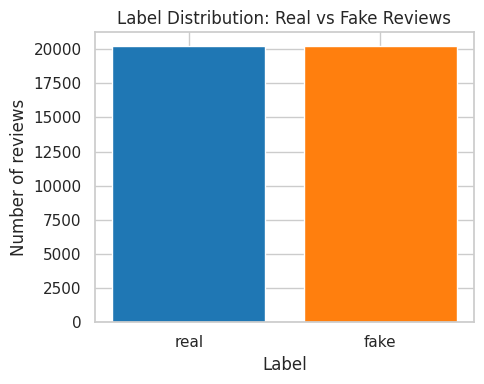

In [19]:
label_counts = df["label_text"].value_counts().reindex(["real", "fake"])

plt.figure(figsize=(5,4))
plt.bar(["real", "fake"],
        [label_counts["real"], label_counts["fake"]],
        color=[color_real, color_fake])
plt.title("Label Distribution: Real vs Fake Reviews")
plt.xlabel("Label")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()


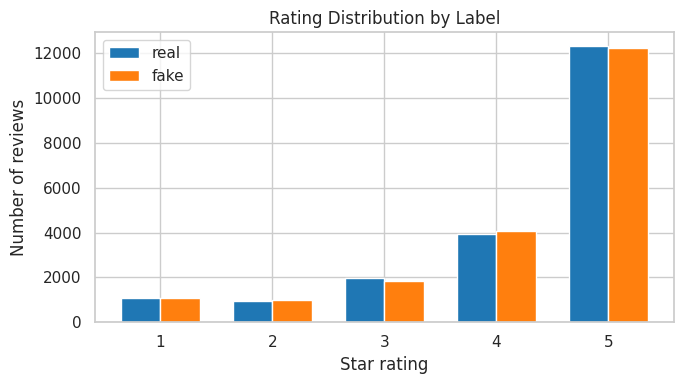

In [20]:
# ========== 4. RATING DISTRIBUTION BY LABEL ==========

ratings = [1,2,3,4,5]

real_counts = (
    df[df["label_text"]=="real"]["rating"]
      .value_counts()
      .reindex(ratings, fill_value=0)
)
fake_counts = (
    df[df["label_text"]=="fake"]["rating"]
      .value_counts()
      .reindex(ratings, fill_value=0)
)

x = np.arange(len(ratings))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, real_counts.values, width,
        label="real", color=color_real)
plt.bar(x + width/2, fake_counts.values, width,
        label="fake", color=color_fake)
plt.xticks(x, ratings)
plt.title("Rating Distribution by Label")
plt.xlabel("Star rating")
plt.ylabel("Number of reviews")
plt.legend()
plt.tight_layout()
plt.show()


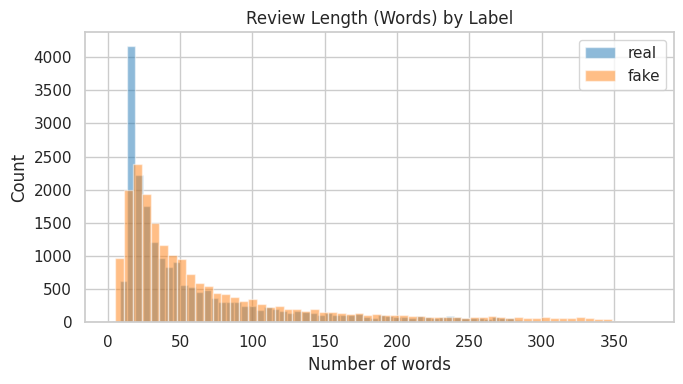

In [21]:
# ========== 5. REVIEW LENGTH HISTOGRAMS BY LABEL ==========

plt.figure(figsize=(7,4))
plt.hist(df[df["label_text"]=="real"]["word_len"],
         bins=60, alpha=0.5, label="real", color=color_real)
plt.hist(df[df["label_text"]=="fake"]["word_len"],
         bins=60, alpha=0.5, label="fake", color=color_fake)
plt.title("Review Length (Words) by Label")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-3334936400.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([real_lengths, fake_lengths],


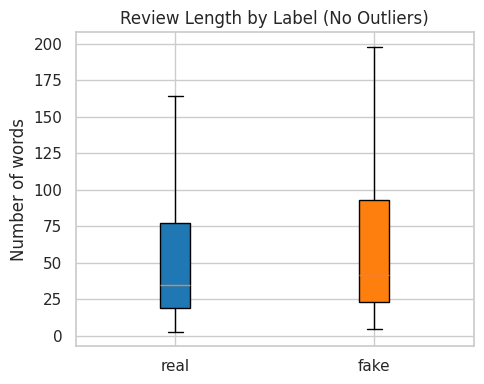

Median length (real): 35.0
Median length (fake): 42.0


In [22]:
# ========== 6. REVIEW LENGTH BOX PLOT ==========

real_lengths = df[df["label_text"]=="real"]["word_len"]
fake_lengths = df[df["label_text"]=="fake"]["word_len"]

plt.figure(figsize=(5,4))
box = plt.boxplot([real_lengths, fake_lengths],
                  labels=["real", "fake"],
                  patch_artist=True,
                  showfliers=False)  # hide extreme outliers

# Color the boxes: blue = real, orange = fake
for patch, col in zip(box['boxes'], [color_real, color_fake]):
    patch.set_facecolor(col)

plt.title("Review Length by Label (No Outliers)")
plt.ylabel("Number of words")
plt.tight_layout()
plt.show()

print("Median length (real):", real_lengths.median())
print("Median length (fake):", fake_lengths.median())


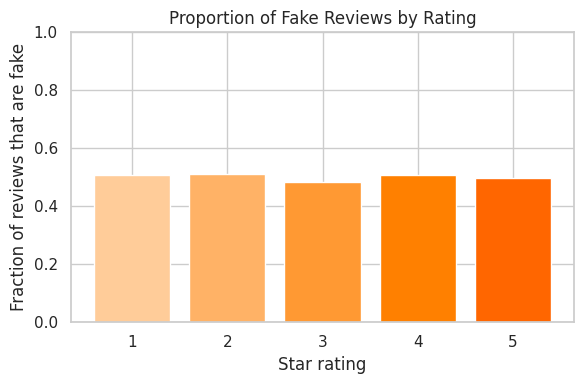

In [23]:
# Different shades of orange for each rating
colors_fake_variants = [
    "#ffcc99",  # rating 1
    "#ffb266",  # rating 2
    "#ff9933",  # rating 3
    "#ff8000",  # rating 4
    "#ff6600"   # rating 5
]

# Calculate fake rate by rating
# This part was missing and caused the NameError
counts = (
    df.groupby(["rating", "label_text"])
      .size()
      .unstack(fill_value=0)
      .reindex(ratings)
)
real_counts = counts["real"]
fake_counts = counts["fake"]
total_counts = real_counts + fake_counts
fake_rate_by_rating = fake_counts / total_counts

plt.figure(figsize=(6,4))
plt.bar(ratings, fake_rate_by_rating.values,
        color=colors_fake_variants)

plt.ylim(0,1)
plt.title("Proportion of Fake Reviews by Rating")
plt.xlabel("Star rating")
plt.ylabel("Fraction of reviews that are fake")
plt.tight_layout()
plt.show()

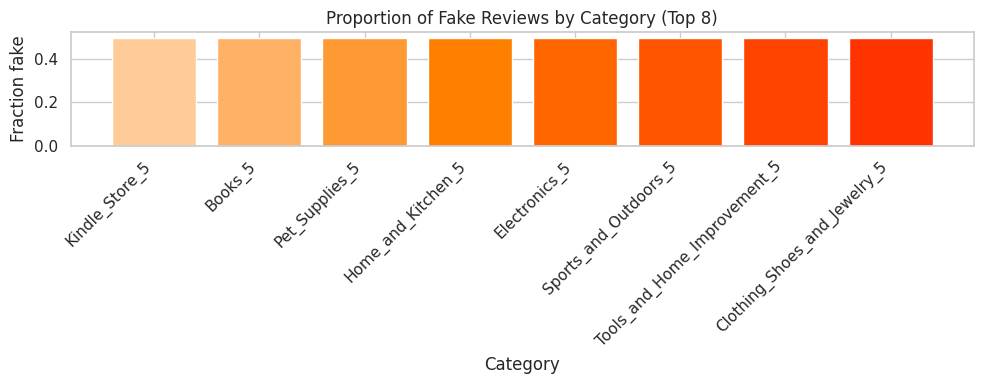

In [24]:
# Different shades of orange for top 8 categories
colors_cat_orange = [
    "#ffcc99",
    "#ffb266",
    "#ff9933",
    "#ff8000",
    "#ff6600",
    "#ff5500",
    "#ff4400",
    "#ff3300"
]

# Calculate fake rate by category for top 8 categories
top8_categories = df["category"].value_counts().nlargest(8).index

# Calculate the mean of label_bin (fake rate) for each category
fake_rate_by_category = df.groupby("category")["label_bin"].mean()

# Filter for top 8 categories and get their fake rates
fake_rate_top8 = fake_rate_by_category.loc[top8_categories]

plt.figure(figsize=(10,4))
plt.bar(top8_categories, fake_rate_top8.values,
        color=colors_cat_orange)

plt.xticks(rotation=45, ha="right")
plt.title("Proportion of Fake Reviews by Category (Top 8)")
plt.xlabel("Category")
plt.ylabel("Fraction fake")
plt.tight_layout()
plt.show()

In [25]:
from collections import Counter

def top_words(texts, n=20):
    all_words = " ".join(texts).split()
    return Counter(all_words).most_common(n)

top_real = top_words(df[df["label_text"]=="real"]["clean_text"], n=20)
top_fake = top_words(df[df["label_text"]=="fake"]["clean_text"], n=20)

print("Top words in REAL reviews:", top_real)
print("\nTop words in FAKE reviews:", top_fake)


Top words in REAL reviews: [('the', 83921), ('a', 57004), ('i', 56984), ('and', 43210), ('is', 40455), ('it', 37705), ('to', 30597), ('this', 26736), ('of', 20395), ('for', 20346), ('very', 14749), ('was', 14649), ('have', 13318), ('that', 12260), ('my', 11387), ('in', 11132), ('with', 10797), ('great', 10641), ('are', 10186), ('book', 9774)]

Top words in FAKE reviews: [('the', 73482), ('and', 44384), ('a', 40122), ('i', 40041), ('to', 37937), ('it', 30906), ('of', 25149), ('is', 24336), ('this', 22434), ('for', 18569), ('in', 18485), ('that', 14400), ('my', 13276), ('with', 12850), ('but', 11825), ('was', 11637), ('on', 10934), ('you', 10072), ('have', 9891), ('not', 9598)]


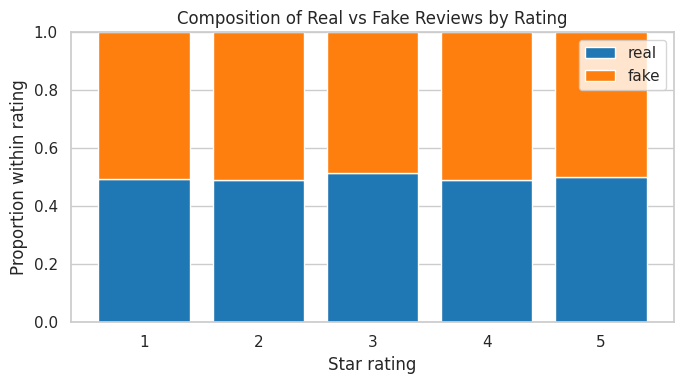

In [26]:
import numpy as np
import matplotlib.pyplot as plt

ratings = [1,2,3,4,5]

# Count real/fake per rating
counts = (
    df.groupby(["rating", "label_text"])
      .size()
      .unstack(fill_value=0)
      .reindex(ratings)
)

real_counts = counts["real"].values
fake_counts = counts["fake"].values
total = real_counts + fake_counts

real_pct = real_counts / total
fake_pct = fake_counts / total

x = np.arange(len(ratings))

plt.figure(figsize=(7,4))
plt.bar(x, real_pct, label="real", color=color_real)
plt.bar(x, fake_pct, bottom=real_pct, label="fake", color=color_fake)

plt.xticks(x, ratings)
plt.ylim(0,1)
plt.title("Composition of Real vs Fake Reviews by Rating")
plt.xlabel("Star rating")
plt.ylabel("Proportion within rating")
plt.legend()
plt.tight_layout()
plt.show()


For every star rating from 1 to 5, the proportion of real and fake reviews is roughly 50% each. This confirms that fake reviews are not concentrated only in extreme ratings; they are uniformly present across all rating levels.

In [27]:
# X = cleaned review text, y = binary label
X = df["clean_text"].values
y = df["label_bin"].values

# Split data (80% train, 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1) DEFINE vectorizer
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=3
)

# 2) TRAIN vectorizer on training text ONLY
tfidf.fit(X_train)

# 3) Transform train + test
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)


In [29]:
from sklearn.linear_model import LogisticRegression

# -------- 1) DEFINE MODEL --------
log_reg = LogisticRegression(
    max_iter=500,
    class_weight="balanced"
)

# -------- 2) TRAIN MODEL --------
log_reg.fit(X_train_tfidf, y_train)

# -------- 3) PREDICT --------
y_pred_lr = log_reg.predict(X_test_tfidf)
y_proba_lr = log_reg.predict_proba(X_test_tfidf)[:, 1]

# -------- 4) EVALUATE --------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)

print("=== Logistic Regression ===")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")


=== Logistic Regression ===
Accuracy : 0.9352
Precision: 0.9255
Recall   : 0.9466
F1 Score : 0.9359


In [30]:
from sklearn.svm import LinearSVC

# -------- 1) DEFINE MODEL --------
svm_clf = LinearSVC()

# -------- 2) TRAIN MODEL --------
svm_clf.fit(X_train_tfidf, y_train)

# -------- 3) PREDICT --------
y_pred_svm = svm_clf.predict(X_test_tfidf)

# -------- 4) EVALUATE --------
acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm  = recall_score(y_test, y_pred_svm)
f1_svm   = f1_score(y_test, y_pred_svm)

print("===  SVM ===")
print(f"Accuracy : {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall   : {rec_svm:.4f}")
print(f"F1 Score : {f1_svm:.4f}")


===  SVM ===
Accuracy : 0.9448
Precision: 0.9403
Recall   : 0.9500
F1 Score : 0.9451


In [31]:
best_model = "Logistic Regression" if f1_lr >= f1_svm else " SVM"
print(f"\nBest model: {best_model}")



Best model:  SVM


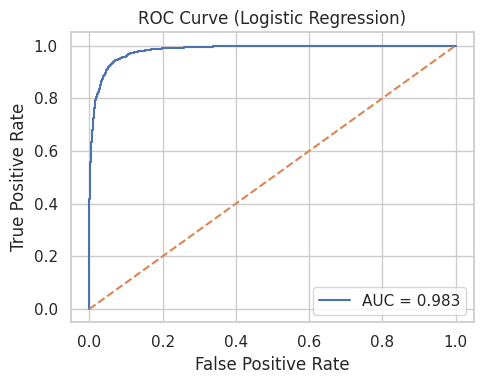

In [32]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")

plt.title("ROC Curve (Logistic Regression)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


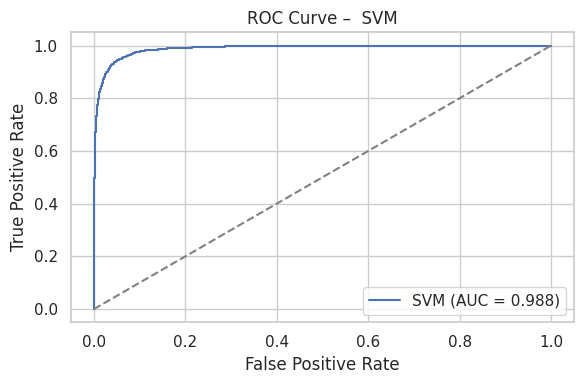

In [33]:
# SVM decision scores
decision_scores_svm = svm_clf.decision_function(X_test_tfidf)

fpr_svm, tpr_svm, _ = roc_curve(y_test, decision_scores_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(6,4))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {roc_auc_svm:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.title("ROC Curve –  SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


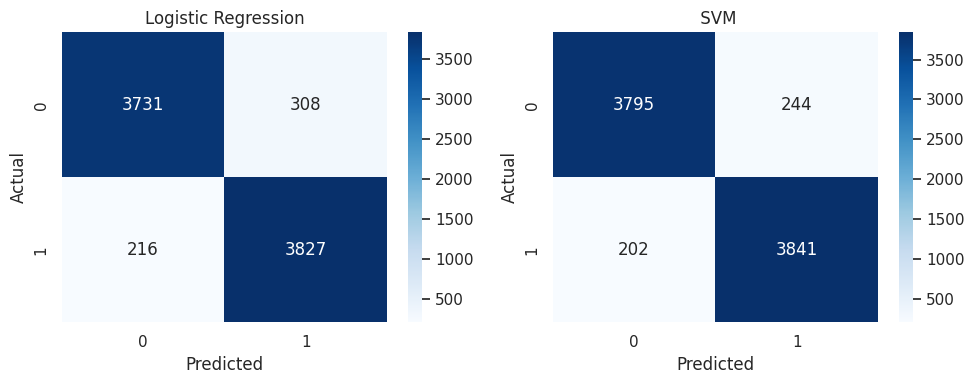

In [34]:
from sklearn.metrics import confusion_matrix

# Confusion matrices
cm_lr  = confusion_matrix(y_test, y_pred_lr)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# SVM
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title(" SVM")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


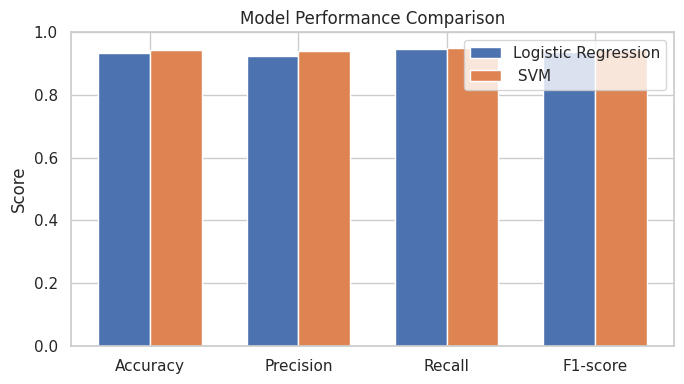

In [35]:
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

lr_scores  = [acc_lr,  prec_lr,  rec_lr,  f1_lr]
svm_scores = [acc_svm, prec_svm, rec_svm, f1_svm]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, lr_scores,  width, label="Logistic Regression")
plt.bar(x + width/2, svm_scores, width, label=" SVM")

plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [36]:
# Build a small DataFrame for inspection
test_df = pd.DataFrame({
    "review_text": X_test,
    "true_label": y_test,
    "pred_label": y_pred_lr,
    "proba_fake": y_proba_lr
})

# Map numeric labels to text
label_map = {0: "real", 1: "fake"}
test_df["true_label_text"] = test_df["true_label"].map(label_map)
test_df["pred_label_text"] = test_df["pred_label"].map(label_map)

# Show 10 random examples
test_df_sample = test_df.sample(10, random_state=42)[
    ["review_text", "true_label_text", "pred_label_text", "proba_fake"]
]

test_df_sample


,review_text,true_label_text,pred_label_text,proba_fake
7588,like normal injinji toe socks this is the only...,real,real,0.167833
2069,still use this card in my old pc with the hdd ...,real,real,0.067663
7622,these work but are a bit pricey and they dont ...,fake,real,0.397928
2063,these pillow cases were purchased for a friend...,real,real,0.093869
8027,this cannister is exactly what it says it is e...,fake,fake,0.953689
3437,nice looking well made comfortable folds and t...,fake,fake,0.791202
6125,not only does this ottoman look nice its comfo...,real,real,0.372010
5100,a fiery horse with the blood of the horse and ...,real,real,0.296860
5499,easy instructions love that they are right on ...,fake,real,0.337344
4522,year old grandson loves this and hes learning ...,fake,fake,0.623913


In [37]:
sample_reviews = [
    "This product is amazing, perfect quality, highly recommended!!!",
    "The item arrived late and the packaging was damaged, but it still works.",
    "Absolutely terrible, do not buy this, it broke after one use.",
    "Great value for the price. I have been using it for two months with no issues."
]

# Use the same cleaning function you used before
def clean_for_model(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned_samples = [clean_for_model(t) for t in sample_reviews]
X_sample_tfidf = tfidf.transform(cleaned_samples)

pred_sample = log_reg.predict(X_sample_tfidf)
proba_sample = log_reg.predict_proba(X_sample_tfidf)[:, 1]

for txt, pred, prob in zip(sample_reviews, pred_sample, proba_sample):
    print("Review:", txt)
    print("Predicted:", "fake" if pred == 1 else "real",
          f"(prob_fake={prob:.2f})")
    print("-" * 80)


Review: This product is amazing, perfect quality, highly recommended!!!
Predicted: fake (prob_fake=0.90)
--------------------------------------------------------------------------------
Review: The item arrived late and the packaging was damaged, but it still works.
Predicted: fake (prob_fake=0.63)
--------------------------------------------------------------------------------
Review: Absolutely terrible, do not buy this, it broke after one use.
Predicted: fake (prob_fake=0.93)
--------------------------------------------------------------------------------
Review: Great value for the price. I have been using it for two months with no issues.
Predicted: real (prob_fake=0.34)
--------------------------------------------------------------------------------


In [38]:
df.to_csv("cleaned_reviews.csv", index=False)


In [39]:
best_model = svm_clf   # or log_reg if logistic was better


In [40]:
import joblib

# save the chosen model
joblib.dump(best_model, "final_model.pkl")

# save the TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Models saved as final_model.pkl and tfidf_vectorizer.pkl")


Models saved as final_model.pkl and tfidf_vectorizer.pkl


## 📊 Model Results

Two linear models were trained and evaluated using TF–IDF features: Logistic Regression and Linear SVM.  
The evaluation was performed on a held-out 20% test set.

---

### **1. Logistic Regression**

- **Accuracy:** 0.9352  
- **Precision:** 0.9255  
- **Recall:** 0.9466  
- **F1-Score:** 0.9359  

Logistic Regression delivered strong performance, with a high F1-score and excellent recall, indicating it successfully identifies a large proportion of fake reviews.

---

### **2. Linear SVM (LinearSVC)**

- **Accuracy:** 0.9448  
- **Precision:** 0.9403  
- **Recall:** 0.9500  
- **F1-Score:** 0.9451  

Linear SVM outperformed Logistic Regression in **every metric**, especially in F1-score, making it the stronger classifier overall.

---

### 🏆 **Best Model: Linear SVM**

Linear SVM achieved the best balance between precision and recall, producing the highest F1-score (0.9451).  
This model was selected as the **final model** for deployment and saved as the `.pkl` file for use in the website backend.

---
